In [1]:
import sys

sys.path.insert(0, "..")

import bttqst._tt as tt
from bttqst._info import Info
from bttqst._data import get_probability_batch
from bttqst._metrics import fidelity, trace_dist, mps_fidelity

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
import math
from scipy.linalg import eigvalsh
import warnings

warnings.filterwarnings("ignore")

In [3]:
info = Info(data_type=torch.complex128, device="cpu")
device, dtype = info.device, info.data_type
device, dtype

('cpu', torch.complex128)

#### Ground Truth State Generation

Random State

In [4]:
N = 5
K = 3
max_rank = 4
row_dims = [2] * N
col_dims = [1] * N
col_dims[N-1] = K

## ground-truth state: rho = A A^H, A a random block-TT factor
tt_rank = [1] + [3]*(N-1) + [1]
cores_a = tt.init_cores(
    row_dims, col_dims, tt_rank, 1, dtype=dtype, device=device, seed=123
)

Orthogonalize and form $\rho_{\mathrm{TT}}$


In [5]:
# rho = A A^H
cores_a = tt.ortho_left(cores_a, 1e-14)
cores_a[-1] = cores_a[-1] / torch.linalg.norm(cores_a[-1])
cores_ahrev = [g.permute(3, 2, 1, 0).conj() for g in cores_a[::-1]]
middle = tt.c_product(cores_a[-1], cores_ahrev[0])
rL, d, d, rR = middle.shape
middle = middle.reshape(rL, d, d, rR)
cores_rho = cores_a[:-1] +[middle] + cores_ahrev[1:]
print(tt.check_tt_orthogonality(cores_rho, N-1))

0: left error 2.39e-16
1: left error 7.61e-16
2: left error 7.51e-16
3: left error 1.41e-15
5: right error 1.42e-15
6: right error 7.52e-16
7: right error 7.27e-16
8: right error 2.39e-16
None


In [6]:
[c.shape for c in cores_rho]

[torch.Size([1, 2, 1, 2]),
 torch.Size([2, 2, 1, 3]),
 torch.Size([3, 2, 1, 3]),
 torch.Size([3, 2, 1, 3]),
 torch.Size([3, 2, 2, 3]),
 torch.Size([3, 1, 2, 3]),
 torch.Size([3, 1, 2, 3]),
 torch.Size([3, 1, 2, 2]),
 torch.Size([2, 1, 2, 1])]

In [7]:
T = tt.cores2ten(cores_rho)
T = T.reshape(T.shape[:N] + T.shape[-N:]) # drops the middle singleton dimensions 
shapeT = T.shape
shapeT

torch.Size([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [8]:
if N <= 10:
    perm = list(range(N)) + list(reversed(range(N, 2*N)))
    Tperm = T.permute(*perm)
    Mat = Tperm.reshape(tt._prod(shapeT[:N]), -1)
    evs = eigvalsh(Mat)
    isherm = all(evs >= -1e-10)
    print(sum(evs), isherm)  # trace and hermicity-positivity

1.0000000000000009 True


In [9]:
N, row_dims, col_dims, tt_rank = tt.get_dimsrank(cores_a)
N, row_dims, col_dims, tt_rank

(5, [2, 2, 2, 2, 2], [1, 1, 1, 1, 3], [1, 2, 3, 3, 3, 1])

In [10]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def flat_band_to_S(Ps, Qs, R):
    """
    Build the sampled mode-N fiber set S (tuples (i_1,...,i_{N-1}),
    i_k in [0, P_k*Q_k)) corresponding to a banded block-diagonal
    pattern in the flattened MPO matrix X_MPO in C^{(P1..PN) x (Q1..QN)}.
    Bandwidth R with step 1 => adjacent diagonal bands overlap,
    mimicking physical correlation decay in a density matrix.

    Requires P_k = Q_k for k=1,...,N-1 so block-row and block-col
    spaces have the same size n_b, making a single diagonal band
    well-defined. Pure index bookkeeping -- kept in NumPy/Python.
    """
    N = len(Ps)
    assert all(Ps[k] == Qs[k] for k in range(N - 1)), \
        "Flat diagonal band requires P_k=Q_k for k=1,...,N-1"
    n_b = int(np.prod(Ps[:N - 1]))
    S = set()
    for br in range(n_b):
        p_multi = np.unravel_index(br, Ps[:N - 1])
        lo, hi = max(0, br - R), min(n_b - 1, br + R)
        for bc in range(lo, hi + 1):
            q_multi = np.unravel_index(bc, Qs[:N - 1])
            i_tuple = tuple(p * Qs[k] + q for k, (p, q) in enumerate(zip(p_multi, q_multi)))
            S.add(i_tuple)
    return S


def patch_for_coverage(S, dims):
    """Adds the minimal extra fiber samples so every unfolding X_n,
    n=1,...,N-2, has full row coverage. Index bookkeeping -- NumPy."""
    N = len(dims)
    S = set(S)
    for n in range(1, N - 1):
        Rd, Md = dims[:n], dims[n:N - 1]
        s2r = {}
        for s in S:
            r = np.ravel_multi_index(s[:n], Rd)
            m = np.ravel_multi_index(s[n:], Md) if len(Md) else 0
            s2r.setdefault(m, set()).add(r)
        covered = set().union(*s2r.values()) if s2r else set()
        R_total = int(np.prod(Rd))
        missing = set(range(R_total)) - covered
        for r in missing:
            r_multi = np.unravel_index(r, Rd)
            m_multi = np.unravel_index(0, Md) if len(Md) else ()
            S.add(tuple(r_multi) + tuple(m_multi))
    return sorted(S)


def reinforce_row_connectivity(S, dims, R, seed=0):
    """Spanning-path reinforcement for R-row-connectivity at every
    split. Index/graph bookkeeping -- NumPy/random, not torch."""
    N = len(dims)
    S = set(S)
    rng = np.random.default_rng(seed)

    for n in range(1, N - 1):
        Rd, Md = dims[:n], dims[n:N - 1]
        n_slices = int(np.prod(Md)) if len(Md) else 1
        n_rows = int(np.prod(Rd)) if n > 0 else 1

        def s2r_now():
            d = {}
            for s in S:
                r = np.ravel_multi_index(s[:n], Rd) if n > 0 else 0
                m = np.ravel_multi_index(s[n:], Md) if len(Md) else 0
                d.setdefault(m, set()).add(r)
            return d

        s2r = s2r_now()
        for m in range(n_slices):
            rows_m = s2r.get(m, set())
            deficit = R - len(rows_m)
            if deficit <= 0:
                continue
            candidates = [r for r in range(n_rows) if r not in rows_m]
            rng.shuffle(candidates)
            m_multi = np.unravel_index(m, Md) if len(Md) else ()
            for r in candidates[:deficit]:
                r_multi = np.unravel_index(r, Rd) if n > 0 else ()
                S.add(tuple(r_multi) + tuple(m_multi))

        s2r = s2r_now()
        for m in range(n_slices - 1):
            m2 = m + 1
            shared = s2r.get(m, set()) & s2r.get(m2, set())
            deficit = R - len(shared)
            if deficit <= 0:
                continue
            candidates = [r for r in range(n_rows) if r not in shared]
            rng.shuffle(candidates)
            m_multi = np.unravel_index(m, Md) if len(Md) else ()
            m2_multi = np.unravel_index(m2, Md) if len(Md) else ()
            for r in candidates[:deficit]:
                r_multi = np.unravel_index(r, Rd) if n > 0 else ()
                S.add(tuple(r_multi) + tuple(m_multi))
                S.add(tuple(r_multi) + tuple(m2_multi))

    return sorted(S)


def row_restricted_connectivity(G):
    """Min # of ROW-nodes whose removal disconnects G, via max-flow.
    NetworkX has no torch backend for max-flow, so this stays as-is."""
    slice_nodes = [v for v in G.nodes if v[0] == "slice"]
    row_nodes = [v for v in G.nodes if v[0] == "row"]
    if len(slice_nodes) < 2:
        return None
    H = nx.DiGraph()
    INF = float("inf")
    for r in row_nodes:
        H.add_edge((r, "in"), (r, "out"), capacity=1)
    for u, v in G.edges():
        row, sl = (u, v) if u[0] == "row" else (v, u)
        H.add_edge(sl, (row, "in"), capacity=INF)
        H.add_edge((row, "out"), sl, capacity=INF)
    min_cut = None
    for i in range(len(slice_nodes)):
        for j in range(i + 1, len(slice_nodes)):
            val, _ = nx.maximum_flow(H, slice_nodes[i], slice_nodes[j], capacity="capacity")
            if min_cut is None or val < min_cut:
                min_cut = val
                if min_cut == 0:
                    return 0
    return min_cut


def verify_conditions(S, dims, R, exact_connectivity=True):
    """Full verification at every split n=1,...,N-2: coverage, some-pair
    overlap>=R, row-restricted connectivity>=R. Plus trivial n=N-1."""
    N = len(dims)
    report = {}
    for n in range(1, N - 1):
        Rd, Md = dims[:n], dims[n:N - 1]
        s2r = {}
        for s in S:
            r = np.ravel_multi_index(s[:n], Rd)
            m = np.ravel_multi_index(s[n:], Md) if len(Md) else 0
            s2r.setdefault(m, set()).add(r)
        R_total = int(np.prod(Rd))
        covered = set().union(*s2r.values()) if s2r else set()
        coverage_ok = len(covered) == R_total

        keys = list(s2r.keys())
        overlap_ok = any(len(s2r[keys[i]] & s2r[keys[j]]) >= R
                          for i in range(len(keys)) for j in range(i + 1, len(keys)))

        rc = None
        conn_ok = True
        if exact_connectivity:
            G = nx.Graph()
            for m, rows in s2r.items():
                for r in rows:
                    G.add_edge(("row", r), ("slice", m))
            rc = row_restricted_connectivity(G) if len(s2r) >= 2 else None
            conn_ok = (rc is None) or (rc >= R)

        report[f"n={n}"] = {
            "coverage": coverage_ok, "rows_covered": len(covered), "rows_total": R_total,
            "some_pair_overlap>=R": overlap_ok,
            "row_restricted_connectivity": rc,
            "OK": coverage_ok and overlap_ok and conn_ok
        }

    report[f"n={N-1}"] = {"|S|": len(S), "required_R": R, "OK": len(S) >= R}
    return report


def sample_to_mpo_blocks(S, Ps, Qs):
    """Convert each mode-N fiber sample to its (block_row, block_col)
    index."""
    N = len(Ps)
    blocks = set()
    for s in S:
        p_pref, q_pref = [], []
        for k in range(N - 1):
            p, q = divmod(s[k], Qs[k])
            p_pref.append(p)
            q_pref.append(q)
        br = np.ravel_multi_index(p_pref, Ps[:N - 1]) if N > 1 else 0
        bc = np.ravel_multi_index(q_pref, Qs[:N - 1]) if N > 1 else 0
        blocks.add((br, bc))
    return blocks


def build_mpo_masks_from_S_torch(S, Ps, Qs, device="cpu"):
    """
    binary masks of shape (P1,...,PN,Q1,...,QN) and (P1,...,PN,QN,...,Q1)
    """
    N = len(Ps)
    shape_PQ = tuple(Ps) + tuple(Qs)
    shape_P_revQ = tuple(Ps) + tuple(reversed(Qs))
    mask_PQ = torch.zeros(shape_PQ, dtype=torch.bool, device=device)
    mask_P_revQ = torch.zeros(shape_P_revQ, dtype=torch.bool, device=device)

    # Build index lists first, then do a single
    # vectorized scatter into the torch tensors instead of a Python loop
    # over every (p_N, q_N) pair per sample.
    idx_PQ = [[] for _ in range(len(shape_PQ))]
    idx_revQ = [[] for _ in range(len(shape_P_revQ))]

    p_N_range = range(Ps[N - 1])
    q_N_range = range(Qs[N - 1])

    for s in S:
        p_pref, q_pref = [], []
        for k in range(N - 1):
            p, q = divmod(s[k], Qs[k])
            p_pref.append(p)
            q_pref.append(q)
        q_pref_rev = list(reversed(q_pref))

        for p_N in p_N_range:
            for q_N in q_N_range:
                full_idx_PQ = tuple(p_pref) + (p_N,) + tuple(q_pref) + (q_N,)
                full_idx_revQ = tuple(p_pref) + (p_N,) + (q_N,) + tuple(q_pref_rev)
                for axis, val in enumerate(full_idx_PQ):
                    idx_PQ[axis].append(val)
                for axis, val in enumerate(full_idx_revQ):
                    idx_revQ[axis].append(val)

    if idx_PQ[0]:
        idx_PQ_t = tuple(torch.tensor(ax, dtype=torch.long, device=device) for ax in idx_PQ)
        idx_revQ_t = tuple(torch.tensor(ax, dtype=torch.long, device=device) for ax in idx_revQ)
        mask_PQ[idx_PQ_t] = True
        mask_P_revQ[idx_revQ_t] = True

    return mask_PQ, mask_P_revQ


def apply_mask_to_mpo(M: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    assert M.shape == mask.shape, f"shape mismatch: M={M.shape}, mask={mask.shape}"
    masked = M * mask.to(M.real.dtype)
    masked[masked==0] = torch.nan    
    return masked

def build_banded_TT_valid_sample(Ps, Qs, R, seed=0, verbose=True):
    """Combinatorial construction: band -> coverage patch -> R-row-
    connectivity reinforcement."""
    dims = tuple(p * q for p, q in zip(Ps, Qs))

    S_band = flat_band_to_S(Ps, Qs, R)
    if verbose:
        print(f"1. Banded base: |S| = {len(S_band)}")

    S_patched = patch_for_coverage(S_band, dims)
    if verbose:
        print(f"2. Patched for coverage: |S| = {len(S_patched)} "
              f"(+{len(S_patched) - len(S_band)})")

    S_final = S_patched # reinforce_row_connectivity(S_patched, dims, R, seed=seed)
    if verbose:
        print(f"3. Reinforced for R-row-connectivity: |S| = {len(S_final)} "
              f"(+{len(S_final) - len(S_patched)})")

    return S_final, dims

In [11]:
Ps, Qs = row_dims, row_dims
R = max(tt_rank)
S, dims = build_banded_TT_valid_sample(Ps, Qs, R, seed=0)

if N<=8:
        print("\n4. Verifying all conditions (exact, authoritative check):")
        report = verify_conditions(S, dims, R, exact_connectivity=False)
        for k, v in report.items():
                print(f"  {k}: {v}")
                all_ok = all(v["OK"] for v in report.values())
                print(f"\nALL CONDITIONS SATISFIED: {all_ok}")

N = len(Ps)
blocks = sample_to_mpo_blocks(S, Ps, Qs)
n_block_rows = int(np.prod(Ps[:N - 1]))
n_block_cols = int(np.prod(Qs[:N - 1]))

mask_PQ, mask_P_revQ = build_mpo_masks_from_S_torch(S, Ps, Qs, device=device)
print(f"\nmask_PQ shape: {tuple(mask_PQ.shape)}, dtype={mask_PQ.dtype}, "
        f"device={mask_PQ.device}, True entries: {mask_PQ.sum().item()}")
print(f"mask_P_revQ shape: {tuple(mask_P_revQ.shape)}, "
        f"True entries: {mask_P_revQ.sum().item()}")

1. Banded base: |S| = 100
2. Patched for coverage: |S| = 130 (+30)
3. Reinforced for R-row-connectivity: |S| = 130 (+0)

4. Verifying all conditions (exact, authoritative check):
  n=1: {'coverage': True, 'rows_covered': 4, 'rows_total': 4, 'some_pair_overlap>=R': True, 'row_restricted_connectivity': None, 'OK': True}

ALL CONDITIONS SATISFIED: True
  n=2: {'coverage': True, 'rows_covered': 16, 'rows_total': 16, 'some_pair_overlap>=R': True, 'row_restricted_connectivity': None, 'OK': True}

ALL CONDITIONS SATISFIED: True
  n=3: {'coverage': True, 'rows_covered': 64, 'rows_total': 64, 'some_pair_overlap>=R': True, 'row_restricted_connectivity': None, 'OK': True}

ALL CONDITIONS SATISFIED: True
  n=4: {'|S|': 130, 'required_R': 3, 'OK': True}

ALL CONDITIONS SATISFIED: True

mask_PQ shape: (2, 2, 2, 2, 2, 2, 2, 2, 2, 2), dtype=torch.bool, device=cpu, True entries: 520
mask_P_revQ shape: (2, 2, 2, 2, 2, 2, 2, 2, 2, 2), True entries: 520


In [12]:
T_obs = apply_mask_to_mpo(T, mask_P_revQ)
T_obs_perm = apply_mask_to_mpo(Tperm, mask_PQ)
mask_P_revQ.shape, T_obs.shape

(torch.Size([2, 2, 2, 2, 2, 2, 2, 2, 2, 2]),
 torch.Size([2, 2, 2, 2, 2, 2, 2, 2, 2, 2]))

In [13]:
(mask_P_revQ.sum()/tt._prod(T.shape))*100

tensor(50.7812)

In [14]:
from bttqst._models import _extend_left_stack, _combine_effective_op, _stack_boundary
from bttqst._newton_cg import optimize_A_via_ncg
from bttqst import objective_and_grad

In [15]:
x = T_obs
order = len(cores_a)
mask = ~torch.isnan(x)
idx = mask.nonzero(as_tuple=False)
y_list = x[mask]
qi_list = idx[:, :order]                   # (M, N): (i1,...,iN)
qj_list  = idx[:, order:order*2]                  # (M, N): (jN,...,j1)

In [16]:
m=1
y_list[m]

tensor(-0.0243+0.0392j, dtype=torch.complex128)

In [17]:
lin_id = qi_list[m].tolist() + qj_list[m].tolist()
x[tuple(lin_id)]

tensor(-0.0243+0.0392j, dtype=torch.complex128)

In [18]:
lin_id

[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]

In [19]:
qi_list[m], qj_list[m], qj_list[m].flip(-1)

(tensor([0, 0, 0, 0, 0]), tensor([0, 0, 0, 0, 1]), tensor([1, 0, 0, 0, 0]))

In [20]:
last_core = cores_a[-1]
rL, d, K, rR = last_core.shape
An = last_core.permute(0, 1, 3, 2).reshape(rL * d * rR, K)

In [21]:
Ob_list = []
M = len(y_list)
for m in range(M):
    Em = torch.zeros((1, order, 2, 2), device=device, dtype=dtype)
    idx = torch.arange(order, device=device)
    Em[0, idx, qi_list[m], qj_list[m].flip(-1)] = 1

    R = torch.ones((1, 1, 1), dtype=dtype, device=device)
    L_cache = [None]*order
    L_cache[0] = _stack_boundary(1, dtype=dtype, device=device) 
    for n in range(order-1):
        L_cache[n + 1] = _extend_left_stack(L_cache[n], cores_a[n], Em[:, n])
    op = _combine_effective_op(L_cache[-1], Em[:, -1], R)

    pred = torch.einsum('ij,bik,kj->b', An.conj(), op, An).conj()
    # print(f"Sample {m}: pred={pred.item()}, true={y_list[m].item()}")
    assert torch.allclose(pred, y_list[m], atol=1e-6), f"Prediction for sample {m} does not match the true value."
    Ob_list.append(op)
Obs = torch.stack(Ob_list, dim=0).squeeze()

In [22]:
ypred = torch.einsum('ij,bik,kj->b', An.conj(), Obs, An).conj()
error = torch.norm(ypred - y_list) / torch.norm(y_list)
print(f"Relative error between predicted and true values: {error.item()}")

Relative error between predicted and true values: 3.7863361320909853e-16


In [23]:
def _randomized_range_sparse(A_csr, At_csr, rank, D, N, n_oversample=10, n_iter=3,
                            dtype=None, device=None):
    """
    Randomized basis computation for a sparse (D, N) CSR tensor (and its CSR transpose).
    """
    k = min(rank + n_oversample, N, D)

    Omega = torch.randn(N, k, dtype=dtype, device=device)
    Y = torch.sparse.mm(A_csr, Omega)                 # (D, k)
    Q, _ = torch.linalg.qr(Y, mode='reduced')

    for _ in range(n_iter):
        Z = torch.sparse.mm(At_csr, Q)                 # (N, k) = A^T Q
        Q, _ = torch.linalg.qr(Z, mode='reduced')
        Y = torch.sparse.mm(A_csr, Q)                  # (D, k) = A Q
        Q, _ = torch.linalg.qr(Y, mode='reduced')

    B = torch.sparse.mm(At_csr, Q).transpose(0, 1)      # (k, N) = Q^T A
    Ub, _, _ = torch.linalg.svd(B, full_matrices=False)
    return Q @ Ub[:, :rank]


def subspace_intersection(T3n, rank=1, randomized=True, n_oversample=10, n_iter=3,
                           dense_threshold=4_000_000):
    """
    T3n: tensor of shape (D, F, S) where S is the number of slices.
         Each slice is a DxF matrix and has NaN values row-wise.
    rank: desired rank of the output subspace.
    """
    D, F, S = T3n.shape
    dtype = T3n.dtype
    device = T3n.device

    # observed mask + counts for ALL slices at once.
    obs_all = ~torch.isnan(T3n[:, 0, :])                 # (D, S), one isnan pass
    n_obs_all = obs_all.sum(dim=0)                       # (S,)
    n_obs_list = n_obs_all.tolist()                      # single sync point

    indices_list = []
    values_list = []
    col_offset = 0
    small_dim = min(F, rank + 6)  

    for s in range(S):
        n_obs = n_obs_list[s]
        if n_obs < rank:
            continue

        obs = obs_all[:, s]
        sl = T3n[:, :, s]
        obs_idx = torch.where(obs)[0]            # ascending
        rows_obs = sl[obs]                       # (n_obs, F)

        # Local basis
        if F <= small_dim + 4:
            U = torch.linalg.svd(rows_obs, full_matrices=False).U[:, :rank]
        else:
            U = torch.svd_lowrank(rows_obs, q=small_dim, niter=n_iter)[0][:, :rank]

        missing = D - n_obs

        rows1 = obs_idx.repeat_interleave(rank)
        cols1 = torch.arange(rank, device=device).repeat(n_obs) + col_offset
        indices_list.append(torch.stack([rows1, cols1], dim=0))
        values_list.append(U.reshape(-1))

        if missing > 0:
            mis_idx = torch.where(~obs)[0]       # ascending
            rows2 = mis_idx
            cols2 = torch.arange(missing, device=device) + col_offset + rank
            indices_list.append(torch.stack([rows2, cols2], dim=0))
            values_list.append(torch.ones(missing, dtype=dtype, device=device))

        col_offset += rank + missing

    if not indices_list:
        print('No slice satisfies the conditions')
        return torch.empty(D, 0, dtype=dtype, device=device)

    indices = torch.cat(indices_list, dim=1)
    values = torch.cat(values_list, dim=0)
    Qtot_sparse = torch.sparse_coo_tensor(indices, values, (D, col_offset)).coalesce()

    N = col_offset
    if randomized and D * N > dense_threshold and min(rank + n_oversample, N, D) < min(D, N):
        A_csr = Qtot_sparse.to_sparse_csr()
        At_csr = Qtot_sparse.transpose(0, 1).coalesce().to_sparse_csr()
        return _randomized_range_sparse(
            A_csr, At_csr, rank, D, N,
            n_oversample=n_oversample, n_iter=n_iter, dtype=dtype, device=device
        )
    else:
        Qtot_dense = Qtot_sparse.to_dense()
        U, _, _ = torch.linalg.svd(Qtot_dense, full_matrices=False)
        return U[:, :rank]

In [24]:
def btt_parallel(x, ranks, K):
    # x is tensor of shape (i1,...,iN, JN, ..., j1) with all entries observed (i1,...,iN, JN, ..., j1)
    # ranks is list of ranks [1, r1, r2, ..., r_{N-1}, 1]
    if x.ndim % 2 != 0:
        raise ValueError('Number of dimensions must be a multiple of 2.')

    order = x.ndim // 2 
    if order < 3:
        raise ValueError('This algorithm requires order >= 3 (tensor of dimension >= 6).')

    shape = x.shape
    row_dims = shape[:order]
    col_dims = shape[order:]

    A = []
    
    for n in range(order):
        if n == order - 1:
            perm = list(range(order-1)) + [order-1, order] + list(range(order+1, 2*order))
            x3n = x.permute(*perm)
            # Reshape: (prod(row[:order-1]), I_{order-1} * I_order, prod(col[1:]))
            x3n = x3n.reshape(
                tt._prod(row_dims[:order-1]),
                row_dims[-1] * col_dims[0],
                tt._prod(col_dims[1:])
            )
            # Compute subspace basis
            U, S, _ = tt.truncated_svd(x3n.reshape(tt._prod(row_dims[:order]), -1), max_rank=K)   
        else:
            perm = list(range(n+1)) + [order-1, order] + \
                    list(range(n+1, order-1)) + list(range(order+1, 2*order))
            x3n = x.permute(*perm)
            # Reshape: (prod(row[:n+1]), I_{order-1} * I_order, prod(row[n+1:-1]) * prod(col[1:]))
            x3n = x3n.reshape(
                tt._prod(row_dims[:n+1]),
                row_dims[-1] * col_dims[0],
                tt._prod(row_dims[n+1:-1]) * tt._prod(col_dims[1:])
            )
            # Compute subspace basis
            U, _, _ = tt.truncated_svd(x3n.reshape(tt._prod(row_dims[:n+1]), -1), max_rank=ranks[n+1])

        A.append(U)

    # First core (mode 0)
    btt_cores = [None]*order
    btt_cores[0] = A[0].reshape(1, A[0].shape[0], 1, A[0].shape[1])    # (1, I1, 1, r1)

    # Intermediate cores (modes 1 .. order-2)
    for ci in range(order - 2):
        left = A[ci].conj().T                               # (r_{ci+1}, prod_{0..ci})
        prod_prev = tt._prod(row_dims[:ci+1])
        right = A[ci+1].reshape(prod_prev, row_dims[ci+1] * ranks[ci+2])
        Wci = left @ right                                   # (r_{ci+1}, I{ci+1}*r_{ci+2})
        btt_cores[ci+1]=  Wci.reshape(ranks[ci+1], row_dims[ci+1], 1, ranks[ci+2])

    # Final core
    ci = order - 2
    left = A[ci].conj().T
    prod_prev = tt._prod(row_dims[:ci+1])
    right = A[ci+1].reshape(prod_prev, row_dims[ci+1] * K)
    W_last = left @ right
    core_last = W_last.reshape(ranks[order-1], row_dims[order-1], 1, K)
    btt_cores[order-1] = torch.einsum('ijlk,kk->ijkl', core_last, torch.diag(torch.sqrt(S)))

    return btt_cores

# cores_rec = btt_parallel(T, tt_rank, K)
# cores_rec_ahrev = [g.permute(3, 2, 1, 0).conj() for g in cores_rec[::-1]]
# middle_rec = tt.c_product(cores_rec[-1], cores_rec_ahrev[0])
# rL, d, d, rR = middle_rec.shape
# middle_rec = middle_rec.reshape(rL, d, d, rR)
# cores_rho_rec = cores_rec[:-1] +[middle_rec] + cores_rec_ahrev[1:]
# print(tt.check_tt_orthogonality(cores_rho_rec, N-1))

In [25]:
def btt_fiberwise(x, ranks, K):
    # x is tensor of shape (i1,...,iN, JN, ..., j1) with some fiber observed (i1,...,iN-1, :, : JN-1, ..., j1)
    # ranks is list of ranks [1, r1, r2, ..., r_{N-1}, 1]
    if x.ndim % 2 != 0:
        raise ValueError('Number of dimensions must be a multiple of 2.')

    order = x.ndim // 2 
    if order < 3:
        raise ValueError('This algorithm requires order >= 3 (tensor of dimension >= 6).')

    shape = x.shape
    row_dims = shape[:order]
    col_dims = shape[order:]

    A = []

    for n in range(order-1):
        perm = list(range(n+1)) + [order-1, order] + \
                list(range(n+1, order-1)) + list(range(order+1, 2*order))
        x3n = x.permute(*perm)
        # Reshape: (prod(row[:n+1]), I_{order-1} * I_order, prod(row[n+1:-1]) * prod(col[1:]))
        x3n = x3n.reshape(
            tt._prod(row_dims[:n+1]),
            row_dims[-1] * col_dims[0],
            tt._prod(row_dims[n+1:-1]) * tt._prod(col_dims[1:])
        )
        # Compute subspace basis
        U = subspace_intersection(x3n, ranks[n+1])
        A.append(U)

    # First core (mode 0)
    btt_cores = [None]*order
    btt_cores[0] = A[0].reshape(1, A[0].shape[0], 1, A[0].shape[1])    # (1, I1, 1, r1)

    # Intermediate cores (modes 1 .. order-2)
    for ci in range(order - 2):
        left = A[ci].conj().T                               # (r_{ci+1}, prod_{0..ci})
        prod_prev = tt._prod(row_dims[:ci+1])
        right = A[ci+1].reshape(prod_prev, row_dims[ci+1] * ranks[ci+2])
        Wci = left @ right                                   # (r_{ci+1}, I{ci+1}*r_{ci+2})
        btt_cores[ci+1]=  Wci.reshape(ranks[ci+1], row_dims[ci+1], 1, ranks[ci+2])


    # Final core: 
    btt_cores[-1] = torch.zeros(ranks[-2], row_dims[-1], K, 1) # trivial-initilization
    mask = ~torch.isnan(x)
    idx = mask.nonzero(as_tuple=False)
    y_list = x[mask]
    qi_list = idx[:, :order]                   # (M, N): (i1,...,iN)
    qj_list  = idx[:, order:]                  # (M, N): (jN,...,j1)
    btt_cores = update_last_btt_core(btt_cores, qi_list, qj_list, y_list, K, ranks, row_dims)
    return btt_cores

def update_last_btt_core(btt_cores, qi_list, qj_list, y_list, K, tt_rank, row_dims):
    d = row_dims[-1] 
    r = tt_rank[-2]               # r_{N-1}
    order = len(btt_cores)            # total number of cores (order)
    dtype = btt_cores[0].dtype
    device = btt_cores[0].device
    K = min(K, r * d)             # cap rank
    btt_cores_rev = [g.permute(3, 2, 1, 0).conj() for g in btt_cores[::-1]]

    rho_mid = torch.zeros(r, d, d, r, dtype=dtype, device=device)
    for i in range(d):
        for j in range(d):
            mask_i = (qi_list[:, order-1] == i)          # i_N
            mask_j = (qj_list[:, 0] == j)            # j_N (because qj_list is jN...j1)
            mask = mask_i & mask_j
            if mask.sum() == 0:
                continue   # slice stays zero

            qi_sub = qi_list[mask]
            qj_sub = qj_list[mask]
            y_sub = y_list[mask]

            A = torch.empty(len(qi_sub), r * r, dtype=dtype, device=device) 
            for m, (quant_i, quant_j) in enumerate(zip(qi_sub, qj_sub)):
                multL = torch.ones(1, 1, dtype=dtype, device=device)
                for k in range(N-1):                    
                    core = btt_cores[k]
                    multL = multL @ core[:, quant_i[k], 0, :]

                multR = torch.ones(1, 1, dtype=dtype, device=device)
                for k in range(order-1):
                    core_adj = btt_cores_rev[-(k+1)]     
                    j_k = quant_j[order-1 - k]               
                    multR = core_adj[:, 0, j_k, :] @ multR

                A[m] = torch.kron(multR.T, multL)        # (1, r*r)

            # Solve least‑squares: A @ vec(G_slice) = y_sub
            x = torch.linalg.lstsq(A, y_sub).solution.squeeze()   # (r*r,)
            rho_mid[:, i, j, :] = x.reshape(r, r).T

    M = rho_mid.permute(0, 1, 3, 2).reshape(r * d, r * d)   # M_{(i,α),(j,β)} = G_{i,α,β,j}
    M = (M + M.conj().T) / 2

    eigvals, eigvecs = torch.linalg.eigh(M)                  # ascending order
    eigvals_K = eigvals[-K:].clamp(min=0.0)                  # largest K, positive
    eigvecs_K = eigvecs[:, -K:]

    # Factor C = U_K * sqrt(Λ_K)   (r*d, K)
    C_big = eigvecs_K * torch.sqrt(eigvals_K).unsqueeze(0)

    # Last core shape: (r, d, K, 1)
    btt_cores[-1] = C_big.reshape(r, d, K, 1)
    return btt_cores

In [26]:
# btt_cores = cores_rec.copy()
# N = len(btt_cores)
# # Left interface
# L = btt_cores[0]
# for k in range(1, N-1):          # k = 1,2,…, N-2
#     L = tt.strong_kronecker(L, btt_cores[k])
# Lk = L.reshape(-1, L.shape[-1])   # shape (total_left_dim, r_{N-2})

# # Right interface
# btt_ahrev = [g.permute(3, 2, 1, 0).conj() for g in btt_cores[::-1]]
# R = btt_ahrev[-1] 
# for k in range(1, N-1):           # k = 1,…, N-2
#     G = btt_ahrev[-(k+1)]         # transformed original k
#     R = tt.strong_kronecker(G, R)
# Rk = R.reshape(R.shape[0], -1)    # shape (r_{N-2}, total_right_dim)

# x = T
# # 4th order reshaping
# left  = int(torch.prod(torch.tensor(x.shape[:N-1])))
# right = int(torch.prod(torch.tensor(x.shape[N+1:])))
# xr = x.reshape(left, x.shape[N-1], x.shape[N], right)
# mask = ~torch.isnan(xr).all(dim=(1,2))

In [27]:
# B = 5
# overlap = 3

# mask = torch.zeros((left, right), dtype=torch.bool)

# # Overlapping block diagonal
# stride = B - overlap
# for s in range(0, min(left, right), stride):
#     e = min(s + B, left, right)
#     mask[s:e, s:e] = True

# # Add random blocks to reach p
# p=0.60
# target = int(round(p * left*right))
# current = int(mask.sum())
# remaining = torch.triu(~mask, diagonal=1).nonzero(as_tuple=False)
# pairs_needed = max(0, (target - current + 1) // 2)

# perm = torch.randperm(remaining.shape[0], device=mask.device)
# idx = remaining[perm[:pairs_needed]]

# mask[idx[:,0], idx[:,1]] = True
# mask[idx[:,1], idx[:,0]] = True

In [28]:
# def hierarchical_symmetric_mask(
#         row_dims,
#         block_size,
#         overlap,
#         p,
#         device="cpu"
# ):
#     """
#     Construct ONE symmetric finest-level TT/MPO sampling mask.

#     The projections of this mask automatically satisfy:
#         - symmetry
#         - row/column coverage
#         - hierarchical coverage

#     row_dims:
#         [I1,I2,...,IN-1]
#         (Hermitian case I=J)

#     Returns:
#         mask : (prod(row_dims), prod(row_dims))
#     """

#     # finest unfolding size
#     L = 1
#     for d in row_dims:
#         L *= d


#     mask = torch.zeros(
#         (L,L),
#         dtype=torch.bool,
#         device=device
#     )


#     # ------------------------------------------------
#     # 1. Overlapping diagonal backbone
#     # ------------------------------------------------
#     stride = block_size - overlap

#     for s in range(0,L,stride):

#         e = min(s+block_size,L)

#         mask[s:e,s:e] = True


#     # symmetry
#     mask = mask | mask.T


#     # ------------------------------------------------
#     # 2. Add minimum random symmetric samples
#     # ------------------------------------------------
#     target = int(p*L*L)

#     current = int(mask.sum())


#     if current < target:

#         # only upper triangle
#         candidates = torch.triu(
#             ~mask,
#             diagonal=1
#         ).nonzero(as_tuple=False)


#         n_edges = (target-current+1)//2

#         n_edges = min(
#             n_edges,
#             candidates.shape[0]
#         )


#         perm = torch.randperm(
#             candidates.shape[0],
#             device=device
#         )[:n_edges]


#         edges = candidates[perm]


#         i = edges[:,0]
#         j = edges[:,1]

#         mask[i,j] = True
#         mask[j,i] = True


#     # ------------------------------------------------
#     # 3. Guarantee every row/column has observation
#     # ------------------------------------------------
#     missing = (~mask.any(dim=1)).nonzero(as_tuple=False)


#     for i in missing:

#         i = int(i)

#         # random symmetric connection
#         j = torch.randint(
#             L,
#             (1,),
#             device=device
#         ).item()

#         mask[i,j] = True
#         mask[j,i] = True


#     return mask

In [29]:
# mask = hierarchical_symmetric_mask(row_dims[:-1], 4, 3, p=0.6)

In [30]:
# mask.shape

In [31]:
# xr_sampled = torch.where(
#     mask[:, None, None, :],
#     xr,
#     torch.full_like(xr, torch.nan)
# )

# x_sampled = xr_sampled.reshape_as(x)
# x_sampled.shape

In [32]:
# plt.imshow(mask)

In [33]:
cores_rec = btt_fiberwise(T_obs, tt_rank, K)
# cores_rec = btt_parallel(T, tt_rank, K)

In [34]:
cores_rec_ahrev = [g.permute(3, 2, 1, 0).conj() for g in cores_rec[::-1]]
middle_rec = tt.c_product(cores_rec[-1], cores_rec_ahrev[0])
rL, d, d, rR = middle_rec.shape
middle_rec = middle_rec.reshape(rL, d, d, rR)
cores_rho_rec = cores_rec[:-1] +[middle_rec] + cores_rec_ahrev[1:]
print(tt.check_tt_orthogonality(cores_rho_rec, N-1))

0: left error 0.00e+00
1: left error 5.22e-16
2: left error 7.73e-16
3: left error 1.14e-15
5: right error 1.17e-15
6: right error 8.10e-16
7: right error 5.19e-16
8: right error 0.00e+00
None


In [35]:
[g.shape for g in cores_rec], [g.shape for g in cores_rec_ahrev]

([torch.Size([1, 2, 1, 2]),
  torch.Size([2, 2, 1, 3]),
  torch.Size([3, 2, 1, 3]),
  torch.Size([3, 2, 1, 3]),
  torch.Size([3, 2, 3, 1])],
 [torch.Size([1, 3, 2, 3]),
  torch.Size([3, 1, 2, 3]),
  torch.Size([3, 1, 2, 3]),
  torch.Size([3, 1, 2, 2]),
  torch.Size([2, 1, 2, 1])])

In [36]:
[c.shape for c in cores_rho_rec]

[torch.Size([1, 2, 1, 2]),
 torch.Size([2, 2, 1, 3]),
 torch.Size([3, 2, 1, 3]),
 torch.Size([3, 2, 1, 3]),
 torch.Size([3, 2, 2, 3]),
 torch.Size([3, 1, 2, 3]),
 torch.Size([3, 1, 2, 3]),
 torch.Size([3, 1, 2, 2]),
 torch.Size([2, 1, 2, 1])]

In [37]:
Trec = tt.cores2ten(cores_rho_rec)
Trec = Trec.reshape(Trec.shape[:N] + Trec.shape[-N:]) 

In [38]:
torch.linalg.norm(T-Trec)/torch.linalg.norm(T)

tensor(7.6300e-15, dtype=torch.float64)

In [39]:
# Left interface
k = N - 1
# cores_rho_rec = cores_rho
C = cores_rho_rec[0]
for G in cores_rho_rec[1:k]:
    C = tt.strong_kronecker(C, G)

Lk = C.reshape(-1, C.shape[-1])

print(Lk.shape)


# Right interface
C = cores_rho_rec[-1]
for G in reversed(cores_rho_rec[k+1:-1]):
    C = tt.strong_kronecker(G, C)

Rk = C.reshape(C.shape[0], -1)

print(Rk.shape)

torch.Size([16, 3])
torch.Size([3, 16])


In [40]:
U,_,_ = tt.truncated_svd(T.reshape(tt._prod(row_dims[:k]), -1), max_rank=tt_rank[-2])
U.shape

torch.Size([16, 3])

In [41]:
k=N-1
dim = tt._prod(row_dims[:k])

rev_idx = (
    torch.arange(dim, device=Lk.device)
    .reshape(*row_dims[:k][::-1])
    .T
    .reshape(-1)
)

P = torch.eye(dim, dtype=Lk.dtype, device=Lk.device)[rev_idx]

print(P.shape, Lk.shape)

torch.Size([16, 16]) torch.Size([16, 3])


In [42]:
torch.linalg.norm(U@U.conj().T - Lk@Lk.conj().T)

tensor(2.5318e-14, dtype=torch.float64)

In [43]:
torch.linalg.norm(U@U.conj().T - P@(Rk.T.conj()@Rk)@P.T)

tensor(2.5318e-14, dtype=torch.float64)

In [44]:
left  = int(torch.prod(torch.tensor(T.shape[:N-1])))
right = int(torch.prod(torch.tensor(T.shape[N+1:])))
Tr = T_obs.reshape(left, T.shape[N-1], T.shape[N], right)
Tr.shape

torch.Size([16, 2, 2, 16])

In [45]:
left  = int(torch.prod(torch.tensor(T.shape[:k])))
right = int(torch.prod(torch.tensor(T.shape[k+2:])))
Tr = T_obs.reshape(left, T.shape[k], T.shape[k+1], right)
Tr.shape

torch.Size([16, 2, 2, 16])

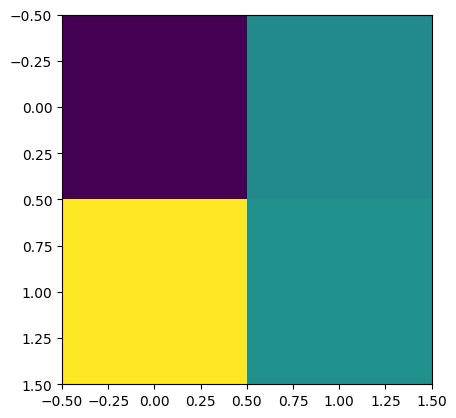

In [46]:
i=0
j=0
plt.imshow(Tr[2,:,:,2].squeeze().real)

In [47]:
i,j=0,1
slice1 = Lk@middle_rec[:,i, j, :]@Rk
slice2 = Tr[:,i, j,:]
slice1.shape, slice2.shape

(torch.Size([16, 16]), torch.Size([16, 16]))

In [48]:
torch.linalg.norm(slice1-slice2)

tensor(nan, dtype=torch.float64)

In [49]:
# N = len(btt_cores)
# # Left interface
# L = btt_cores[0]
# for k in range(1, N-1):          # k = 1,2,…, N-2
#     L = tt.strong_kronecker(L, btt_cores[k])
# Lk = L.reshape(-1, L.shape[-1])   # shape (total_left_dim, r_{N-2})

# # Right interface
# btt_ahrev = [g.permute(3, 2, 1, 0).conj() for g in btt_cores[::-1]]
# R = btt_ahrev[-1] 
# for k in range(1, N-1):           # k = 1,…, N-2
#     G = btt_ahrev[-(k+1)]         # transformed original k
#     R = tt.strong_kronecker(G, R)
# Rk = R.reshape(R.shape[0], -1)    # shape (r_{N-2}, total_right_dim)

In [50]:
mask = ~torch.isnan(T_obs)
idx = mask.nonzero(as_tuple=False)
y_list = T_obs[mask]
qi_list = idx[:, :N]                   # (M, N): (i1,...,iN)
qj_list  = idx[:, N:]                  # (M, N): (jN,...,j1)

A = torch.empty(len(y_list), tt_rank[-2] * tt_rank[-2], dtype=dtype, device=device)
vfull = []
for m in range(len(y_list)):
    quant_i = qi_list[m]
    quant_j = qj_list[m]
    assert T[list(quant_i)+list(quant_j)]==y_list[m] # satisfied

    multL = torch.ones(1, 1, dtype=dtype, device=device)
    for k in range(N-1):                     # k = 0 … N-2
        core = cores_a[k]
        multL = multL @ core[:, quant_i[k], 0, :]

    multR = torch.ones(1, 1, dtype=dtype, device=device)
    for k in range(N-1):
        core = cores_ahrev[-(k+1)]            
        j_k = quant_j[N-1 - k]                      
        multR = core[:, 0, j_k, :] @ multR 
        
    A[m] = torch.kron(multR.T, multL) 
    G_slice = middle[:, quant_i[N-1], quant_j[0], :]   # (r_{N-1}, r_N)
    v = G_slice.T.reshape(-1) 
    vfull.append(v)
    error = A[m]@v-y_list[m]
    print('error for m={} is {}'.format(m, error.abs()))
    if error.abs()>1e-10:
        print('not satisfied for m={}'.format(m))
        break

error for m=0 is 1.3985787785349405e-17
error for m=1 is 1.5515838457795457e-17
error for m=2 is 6.938893903907228e-18
error for m=3 is 9.199760500100245e-18
error for m=4 is 2.6020852139652106e-18
error for m=5 is 1.471961680016039e-17
error for m=6 is 6.938893903907228e-18
error for m=7 is 1.0728672184036493e-17
error for m=8 is 8.673617379884035e-18
error for m=9 is 7.152448122690996e-18
error for m=10 is 1.0417371955916405e-17
error for m=11 is 6.938893903907228e-18
error for m=12 is 5.675257281615581e-18
error for m=13 is 1.0408340855860843e-17
error for m=14 is 3.705370968959021e-18
error for m=15 is 1.214306433183765e-17
error for m=16 is 4.9065389333867974e-18
error for m=17 is 7.757919228897728e-18
error for m=18 is 1.734723475976807e-18
error for m=19 is 5.204170427930421e-18
error for m=20 is 6.938893903907228e-18
error for m=21 is 9.055522398700297e-18
error for m=22 is 7.757919228897728e-18
error for m=23 is 2.168404344971009e-17
error for m=24 is 3.878959614448864e-18
err

In [51]:
y_list[m]

tensor(0.0222-1.3010e-18j, dtype=torch.complex128)

In [52]:
A.shape, G.shape, v.shape

(torch.Size([520, 9]), torch.Size([3, 1, 2, 3]), torch.Size([9]))

In [53]:
torch.norm(A[m]@v-y_list[m])

tensor(1.3010e-18, dtype=torch.float64)

In [54]:
vf = torch.stack(vfull)
vf.shape

torch.Size([520, 9])

In [55]:
A.shape

torch.Size([520, 9])

In [56]:
mask = ~torch.isnan(T_obs)
idx = mask.nonzero(as_tuple=False)           # (M, 2N)
y_list = T_obs[mask]                         # (M,)
qi_list = idx[:, :N]                         # (M, N) – (i1, …, iN)
qj_list = idx[:, N:]                         # (M, N) – (jN, …, j1) 

i_idx = qi_list[:, -1]
j_idx = qj_list[:, 0]

# Build a dictionary mapping (i,j) -> list of observation indices
from collections import defaultdict
groups = defaultdict(list)
for m, (i, j) in enumerate(zip(i_idx.tolist(), j_idx.tolist())):
    groups[(i, j)].append(m)


rL = tt_rank[-2]      
rR = tt_rank[-2]  

A_full = torch.empty(len(y_list), rL * rR, dtype=dtype, device=device)
for m in range(len(y_list)):
    quant_i = qi_list[m]
    quant_j = qj_list[m]

    multL = torch.ones(1, 1, dtype=dtype, device=device)
    for k in range(N-1):
        core = cores_a[k]
        multL = multL @ core[:, quant_i[k], 0, :]

    multR = torch.ones(1, 1, dtype=dtype, device=device)
    for k in range(N-1):
        core = cores_ahrev[-(k+1)]
        j_k = quant_j[N-1 - k]
        multR = core[:, 0, j_k, :] @ multR

    A_full[m] = torch.kron(multR.T, multL)


new_middle = torch.zeros(rL, d, d, rR, dtype=dtype, device=device)

for (i, j), obs_list in groups.items():
    # Extract submatrix and target values
    rows = torch.tensor(obs_list, device=device, dtype=torch.long)
    A_sub = A_full[rows]                     # (K, rL*rR)
    y_sub = y_list[rows]                     # (K,)

    # Solve least‑squares:  A_sub @ v = y_sub
    result = torch.linalg.lstsq(A_sub, y_sub.unsqueeze(-1))
    v_opt = result.solution.squeeze(-1)      # (rL*rR,).
    G_slice = v_opt.reshape(rR, rL).T        # -> (rL, rR)
    new_middle[:, i, j, :] = G_slice

# ----------------------------------------------------------------------
# 6. Verify that the residual is now zero
# ----------------------------------------------------------------------
with torch.no_grad():
    for m in range(len(y_list)):
        quant_i = qi_list[m]
        quant_j = qj_list[m]
        i = quant_i[-1].item()
        j = quant_j[0].item()
        v = new_middle[:, i, j, :].T.reshape(-1)
        pred = A_full[m] @ v
        err = (pred - y_list[m]).abs()
        if err > 1e-10:
            print(f"Residual for m={m}: {err.item():.3e}")
    else:
        print("All residuals < 1e-10 – middle tensor is optimal.")

All residuals < 1e-10 – middle tensor is optimal.


In [57]:
Gr = new_middle.permute(0, 1, 3, 2).reshape(tt_rank[-2]*d, d*tt_rank[-2])
Gr.shape

torch.Size([6, 6])

In [58]:
s = torch.linalg.svdvals(Gr)

In [59]:
torch.allclose(Gr, Gr.conj().T)

True

In [60]:
torch.allclose(new_middle, new_middle.conj().T)

True